# 2025 문화 디지털혁신 및 문화데이터 활용 공모전
## 팀명 : 잡초단
```
공모 분야 : 데이터 분석
분석 주제 : K-트레킹 코스 유형 분석 및 맞춤 추천 시스템 개발
```

## 1. 의존성 관리

### - 기본 라이브러리 및 한글폰트 깨짐 방지

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

import os
if os.name == 'posix' :
    plt.rc('font', family='AppleGothic')
else :
    plt.rc('font', family='Malgun Gothic')

plt.rc('axes', unicode_minus=False)

# 클러스터링 경고메시지 처리
os.environ["OMP_NUM_THREADS"] = "1"

### - 데이터 생성 관련 라이브러리

In [ ]:
import ast
# 위도 경도 변환 (TM → 위도/경도)
from pyproj import Transformer

### - 머신러닝 라이브러리 관리

In [ ]:
from sklearn.decomposition import PCA # 차원 축소 - 주성분
from sklearn.preprocessing import StandardScaler, MinMaxScaler # 스케일링
from sklearn.cluster import KMeans # 거리 기반 클러스터링
from sklearn.metrics import silhouette_score # 실루엣점수

## 2. 데이터 생성
> 사업장 일반정보(숙박업 사업장), 사업장 위치좌표(숙박업 사업장), 전국일반음식점표준데이터 데이터 활용하여 출발지로부터의(위도, 경도 기준) 음식점 및 숙박업소 개수별 거리 구하기

- 예시 데이터 불러오기

- 1. 음식점 데이터

In [ ]:
food_data_open = pd.read_csv('./data/전국일반음식점표준데이터.csv', encoding='cp949')
food_data_open.head()

C:\Users\kmj24\AppData\Local\Temp\ipykernel_17344\967340050.py:1: DtypeWarning: Columns (11,39,44,45) have mixed types. Specify dtype option on import or set low_memory=False.
  food_data_open = pd.read_csv('./data/전국일반음식점표준데이터.csv', encoding='cp949')


,번호,개방서비스명,개방서비스아이디,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태구분코드,영업상태명,상세영업상태코드,...,공장생산직직원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지,Unnamed: 47
0,1,일반음식점,07_24_04_P,3250000,3250000-101-2024-00139,2024-12-02,NaN,3,폐업,2,...,0.0,NaN,0.0,0.0,N,0.0,NaN,NaN,NaN,NaN
1,2,일반음식점,07_24_04_P,3250000,3250000-101-2024-00138,2024-12-02,NaN,3,폐업,2,...,0.0,NaN,0.0,0.0,N,0.0,NaN,NaN,NaN,NaN
2,3,일반음식점,07_24_04_P,4070000,4070000-101-2024-00307,2024-12-02,NaN,3,폐업,2,...,0.0,NaN,0.0,0.0,N,18.0,NaN,NaN,NaN,NaN
3,4,일반음식점,07_24_04_P,3420000,3420000-101-2024-00355,2024-12-02,NaN,3,폐업,2,...,0.0,NaN,0.0,0.0,N,8.0,NaN,NaN,NaN,NaN
4,5,일반음식점,07_24_04_P,4311000,4311000-101-2025-00013,2025-01-06,NaN,3,폐업,2,...,0.0,NaN,0.0,0.0,N,0.0,NaN,NaN,NaN,NaN


In [ ]:
# 영업상태명 폐업과 영업/정상으로 나뉨
print(f"영업상태명 의 종류 : {food_data_open['영업상태명'].unique()}")

# 영업/정상인 데이터만 남기기
food_data_open = food_data_open[food_data_open['영업상태명']=='영업/정상']
print(f"영업상태명 의 종류 : {food_data_open['영업상태명'].unique()}")

영업상태명 의 종류 : ['폐업' '영업/정상']
영업상태명 의 종류 : ['영업/정상']


In [ ]:
food_data_open.columns

Index(['번호', '개방서비스명', '개방서비스아이디', '개방자치단체코드', '관리번호', '인허가일자', '인허가취소일자',
       '영업상태구분코드', '영업상태명', '상세영업상태코드', '상세영업상태명', '폐업일자', '휴업시작일자', '휴업종료일자',
       '재개업일자', '소재지전화', '소재지면적', '소재지우편번호', '소재지전체주소', '도로명전체주소', '도로명우편번호',
       '사업장명', '최종수정시점', '데이터갱신구분', '데이터갱신일자', '업태구분명', '좌표정보x(epsg5174)',
       '좌표정보y(epsg5174)', '위생업태명', '남성종사자수', '여성종사자수', '영업장주변구분명', '등급구분명',
       '급수시설구분명', '총직원수', '본사직원수', '공장사무직직원수', '공장판매직직원수', '공장생산직직원수',
       '건물소유구분명', '보증액', '월세액', '다중이용업소여부', '시설총규모', '전통업소지정번호', '전통업소주된음식',
       '홈페이지', 'Unnamed: 47'],
      dtype='object')

- 2. 숙박업소 데이터

In [ ]:
# 주소 포함된 데이터
stay_data_address =  pd.read_csv('./data/사업장일반정보_야놀자_202412.csv')
stay_data_address.head()

,LDGS_CD,LDGS_NM,LDGS_ZIP_NO,LDGS_ROAD_NM_ADDR
0,23184,영등포 라이프스타일 F HOTEL,7306,서울 영등포구 경인로108길 8 (영등포동1가)
1,23192,청주 오창 M+,28118,충청북도 청주시 청원구 오창읍 양청송대길 9-12
2,23197,강남 렉시,6235,서울특별시 강남구 테헤란로16길 11
3,23204,대전 유성 시나브로,34185,대전광역시 유성구 온천북로59번길 9
4,23206,부천(상동) MY HOTEL,14542,경기도 부천시 길주로121번길 18-11(상동)


In [ ]:
# 위치 좌표 표함된 데이터
stay_data_cd =  pd.read_csv('./data/사업장위치좌표_야놀자_202412.csv')
stay_data_cd.head()

,LDGS_CD,LDGS_NM,LDGS_LA,LDGS_LO
0,23184,영등포 라이프스타일 F HOTEL,37.517182,126.911217
1,23192,청주 오창 M+,36.713884,127.439228
2,23197,강남 렉시,37.498792,127.033956
3,23204,대전 유성 시나브로,36.356873,127.349172
4,23206,부천(상동) MY HOTEL,37.506612,126.756644


In [ ]:
# 주소와 위치 좌표 데이터 합치기
final_stay_data = pd.merge(stay_data_address, stay_data_cd,  on="LDGS_CD",  how="left")
final_stay_data.head()

,LDGS_CD,LDGS_NM_x,LDGS_ZIP_NO,LDGS_ROAD_NM_ADDR,LDGS_NM_y,LDGS_LA,LDGS_LO
0,23184,영등포 라이프스타일 F HOTEL,7306,서울 영등포구 경인로108길 8 (영등포동1가),영등포 라이프스타일 F HOTEL,37.517182,126.911217
1,23192,청주 오창 M+,28118,충청북도 청주시 청원구 오창읍 양청송대길 9-12,청주 오창 M+,36.713884,127.439228
2,23197,강남 렉시,6235,서울특별시 강남구 테헤란로16길 11,강남 렉시,37.498792,127.033956
3,23204,대전 유성 시나브로,34185,대전광역시 유성구 온천북로59번길 9,대전 유성 시나브로,36.356873,127.349172
4,23206,부천(상동) MY HOTEL,14542,경기도 부천시 길주로121번길 18-11(상동),부천(상동) MY HOTEL,37.506612,126.756644


- 3. 팔공산 데이터를 예시로 가져오기
> 국립공원공단 사이트 기준으로 생성한 데이터프레임

In [ ]:
palgong_reference_df = pd.read_excel('./data/PG_GR_course_df.xlsx')
palgong_reference_df.head(3)

,mountain_name,course_name,course_id,start_point_name,start_point_id,출발지 주소(임시),인근 주차장 주소(임시),start_lat,start_lon,end_point_name,...,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,대구 동구 팔공산로 1037-10,수태골 주차장\n대구 동구 용수동 907-1,35.99384,128.68139,동봉,...,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,중,19:46:00,17:22:00,0,0.143,1
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,경북 칠곡군 동명면 남원리 629-1(진남문)\n경상북도 칠곡군 동명면 가산산성길 ...,가산산성남문 공영주차장입구\n경북 칠곡군 동명면 남원리 산 1-1,36.02121,128.59080,가산봉,...,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,하,19:45:00,17:21:00,0,0.066,1
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,경북 영천시 신녕면 치산리 311,수도사\n경상북도 영천시 신녕면 치산리 311,36.04313,128.71520,동봉,...,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,중,19:45:00,17:21:00,0,0.735,1


- 4. 음식점 및 숙박업소 개수별 거리 구하기

In [ ]:
# 좌표계 변환기 정의 (5174 → 4326)
transformer = Transformer.from_crs("EPSG:5174", "EPSG:4326", always_xy=True)

# 음식점 X, Y → 경도, 위도로 변환
food_data_open['lon'], food_data_open['lat'] = transformer.transform(
    food_data_open['좌표정보x(epsg5174)'], food_data_open['좌표정보y(epsg5174)']
)

In [ ]:
# 위도,경도로 거리 구하기
R = 6371

# Haversine 벡터 함수
def haversine_np(lat1, lon1, lat2_array, lon2_array):
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2_array, lon2_array = np.radians(lat2_array), np.radians(lon2_array)

    dlat = lat2_array - lat1
    dlon = lon2_array - lon1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2_array) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c  # km

# 음식점 거리 계산 함수 (영업상태 영업/정상 인 부분만 추출하여 진행!!)
def calc_food_distances(reference_df, food_df, stay_counts=[1, 50, 70, 100]):
    food_lat = food_df['lat'].values
    food_lng = food_df['lon'].values

    results = []

    for _, row in reference_df.iterrows():
        origin_lat, origin_lng = row['start_lat'], row['start_lon']
        place_id = row['course_id']

        dists = haversine_np(origin_lat, origin_lng, food_lat, food_lng)
        dists.sort()

        res = {'course_id': place_id}
        for n in stay_counts:
            if len(dists) >= n:
                res[f'dist_to_{n}_foods'] = round(dists[n-1], 2)
            else:
                res[f'dist_to_{n}_foods'] = None
        results.append(res)

    return pd.DataFrame(results)

# 숙박업소 거리 계산 함수
def calc_stay_distances(reference_df, stay_df, stay_counts=[1, 10, 20, 30]):
    stay_lat = stay_df['LDGS_LA'].values
    stay_lng = stay_df['LDGS_LO'].values

    results = []

    for _, row in reference_df.iterrows():
        origin_lat, origin_lng = row['start_lat'], row['start_lon']
        place_id = row['course_id']

        dists = haversine_np(origin_lat, origin_lng, stay_lat, stay_lng)
        dists.sort() # numpy라서 sort! 시리즈면 sort_values

        res = {'course_id': place_id}
        for n in stay_counts:
            if len(dists) >= n:
                res[f'dist_to_{n}_stays'] = round(dists[n-1], 2)
            else:
                res[f'dist_to_{n}_stays'] = None
        results.append(res)

    return pd.DataFrame(results)

- 사용 예시

In [ ]:
# 사용예시
# 팔공산용 숙박업소 거리 계산
palgong_stay_df = calc_stay_distances(palgong_reference_df, final_stay_data)

In [ ]:
palgong_stay_df.head()

,course_id,dist_to_1_stays,dist_to_10_stays,dist_to_20_stays,dist_to_30_stays
0,PG_01,0.82,4.70,6.22,7.41
1,PG_02,1.28,2.70,5.47,9.02
2,PG_03,1.76,6.60,8.77,10.66
3,PG_04,2.69,7.92,10.07,12.43
4,PG_05,1.49,4.89,5.89,6.75


> 위의 방법으로 생성된 산마다의 숙박업소 및 음식점 개수별 거리 계산한 데이터를 "인프라" 데이터로 내보내기

## 3. EDA

### 3-1. 최종 데이터 불러오기

In [ ]:
# 최종 생성한 데이터 불러오기
merge_df = pd.read_csv('./data/merge_mountain_df.csv')
merge_df.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,...,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,...,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,...,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,...,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,...,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3-2. 데이터 분포 확인

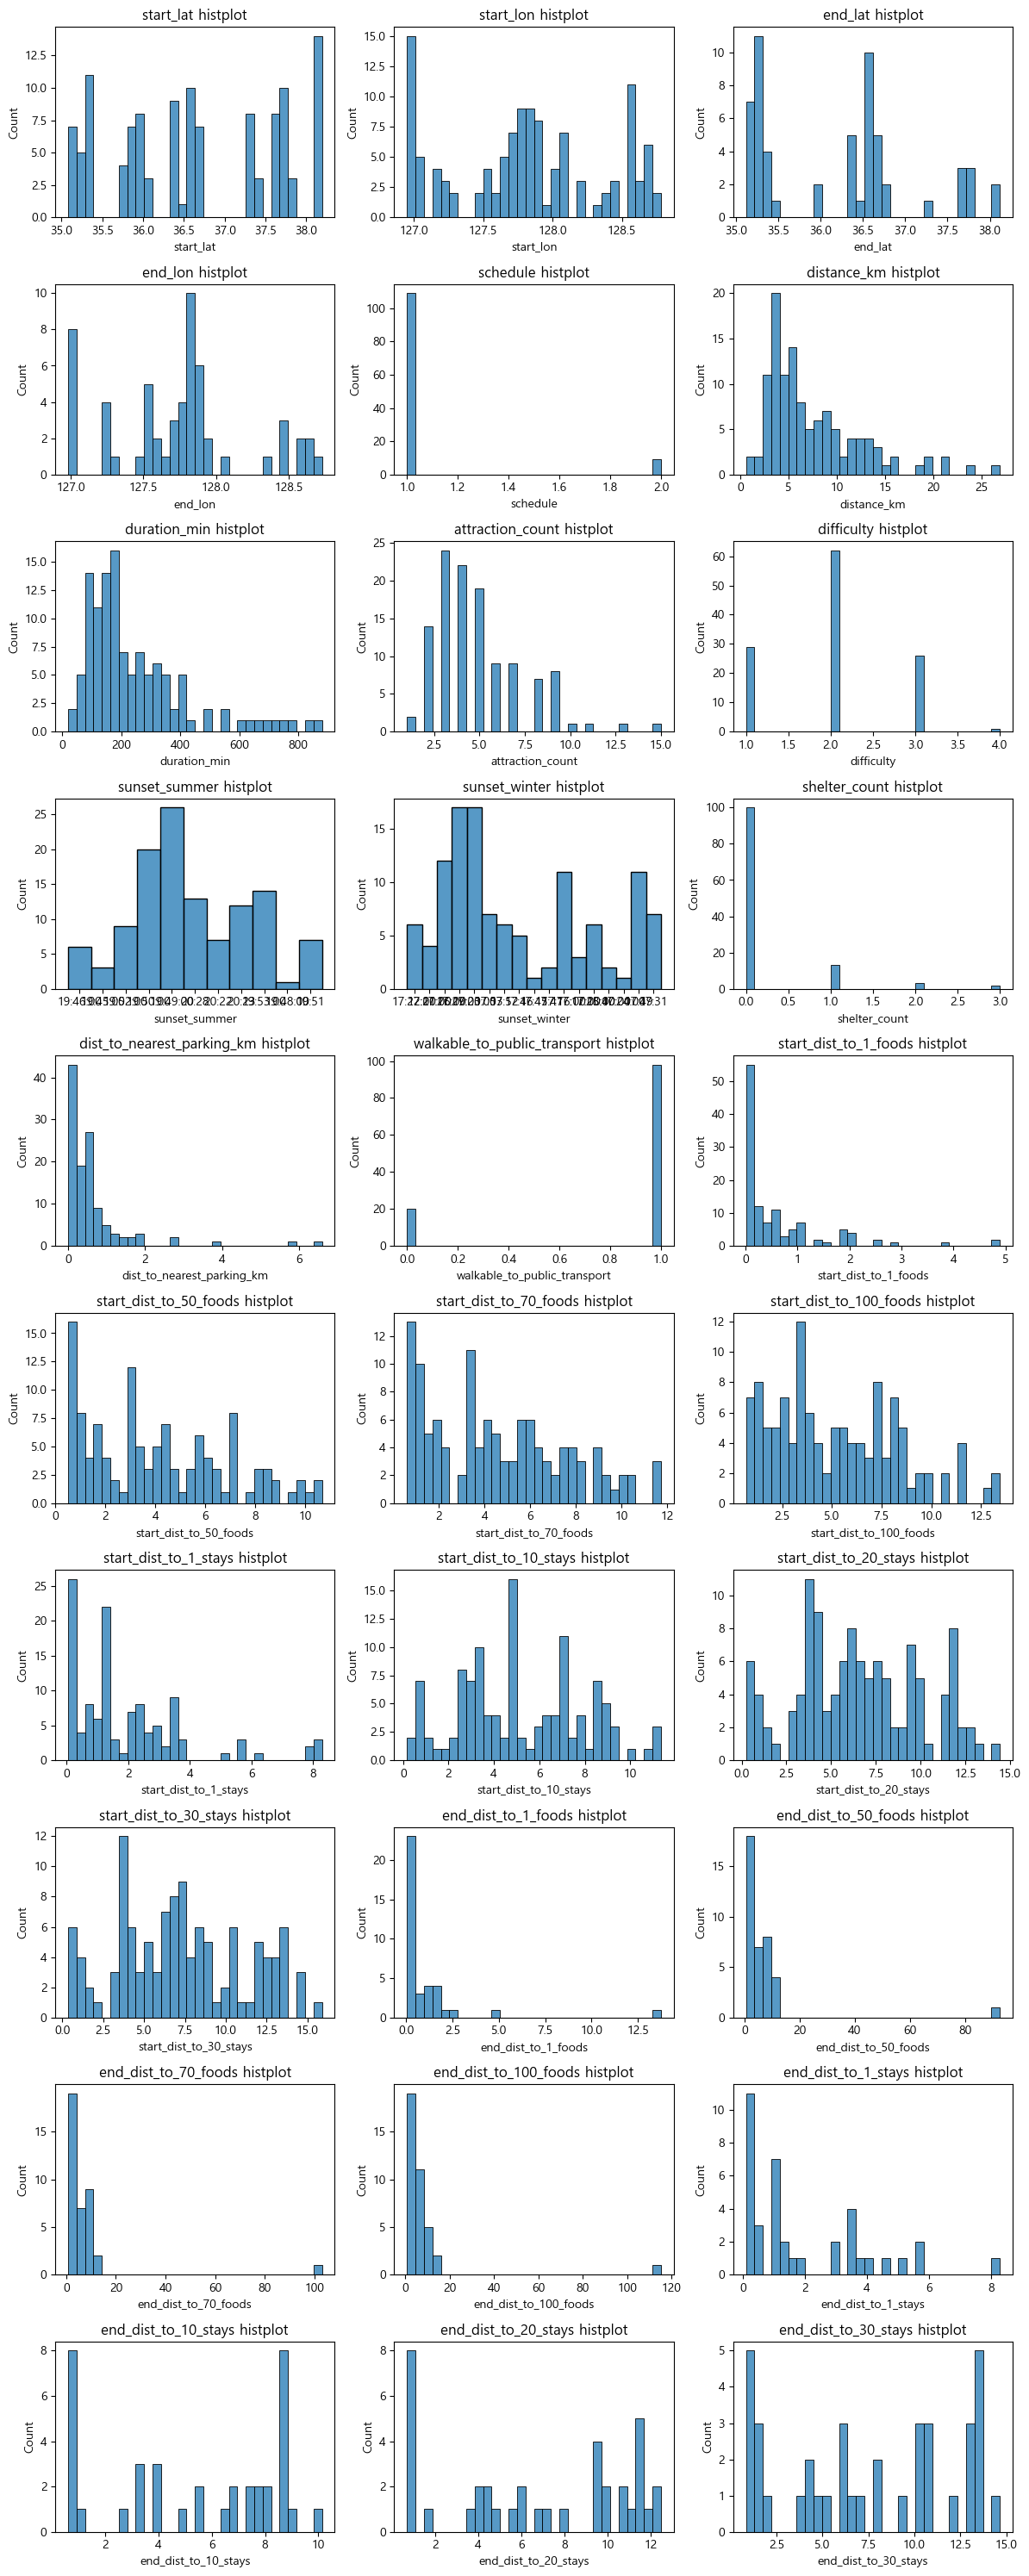

In [ ]:
# object 타입 혹은 구분자 역할을 하는 id 컬럼들 제거
col = list(merge_df.drop(columns=['mountain_name', 'course_name', 'course_id', 'start_point_name',
       'start_point_id','end_point_name','end_point_id','attraction_list', 'start_place_ID','end_place_ID']).columns)

def hist_subplots(dataFrame, col_cnt, bin_cnt) :
    # 3개의 컬럼으로 형성되는 subplots
    col_count = col_cnt
    #  // 는 버림처리가 되지만, 현재는 올림처리가 필요하므로 음수를 활용해서 절대값이 올림처리 되게 한 다음 다시 음수를 추가해서 양수 변환시키기
    row_count = -(-len(col)//col_count)

    # subplots 형태
    fig, axs = plt.subplots(row_count, col_count, figsize=(col_count*4, row_count*3))
    # 접근을 위한 1차원 변환
    axs = axs.flatten()

    for i, c in enumerate(col) :
        sns.histplot(data=dataFrame, x=c, bins=bin_cnt, ax = axs[i])
        axs[i].set_title(c +' histplot')

    plt.tight_layout()
    plt.show()

hist_subplots(merge_df, 3, 30)

- 일부 데이터는 한쪽으로 치우는 경향
- 전반적으로 정규분포를 따르지 않음
    - -> elbow method로 k개수 찾기


### 3-3. 전처리
>  ‘dist_to_nearest_parking_km’ 는 연속형 변수로서 탐방객의 코스 접근편의성에 직접적인 영향을미치는 변수
> 이상치를 제거하거나 그대로 유지하기 보다는 사분위수 기반 범주화 처리

In [ ]:
# 사분위수 기준값 구하기
q1 = merge_df['dist_to_nearest_parking_km'].quantile(0.25)
q2 = merge_df['dist_to_nearest_parking_km'].quantile(0.50)
q3 = merge_df['dist_to_nearest_parking_km'].quantile(0.75)

# 박스플롯 기준 상한 (이상치 기준값)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# 라벨링 함수 정의
def label_parking_dist(x):
    if x > upper_bound:
        return 4  # 이상치
    elif x <= q1:
        return 0
    elif x <= q2:
        return 1
    elif x <= q3:
        return 2
    else:
        return 3

# 적용
merge_df['dist_to_nearest_parking_km_label'] = merge_df['dist_to_nearest_parking_km'].apply(label_parking_dist)
merge_df.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,dist_to_nearest_parking_km_label
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


### 3-4. 속성 간의 상관계수 확인

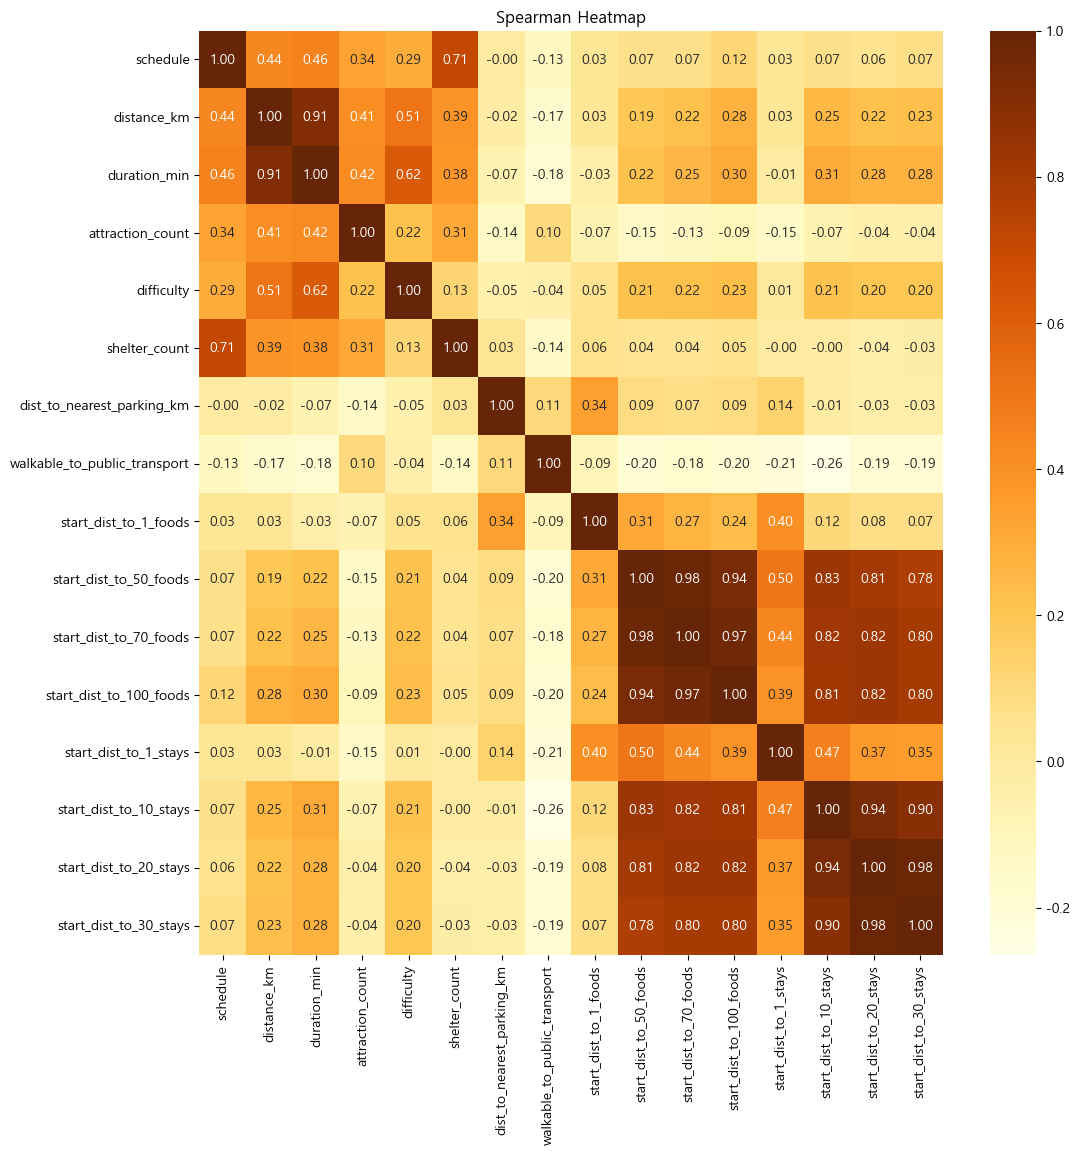

In [ ]:
# id 와 같은 컬럼 제거해서 히트맵 확인
# 순서 중심의 클러스터링 진행할 변수들만 추출해서 피어슨 상관계수 구하기

# 일몰 시간은 수치형 변수라고 하기 어려워서 우선 제거

df_heatmap = merge_df[['schedule', 'distance_km','duration_min','attraction_count', 'difficulty',
        'shelter_count',
       'dist_to_nearest_parking_km', 'walkable_to_public_transport',
       'start_dist_to_1_foods', 'start_dist_to_50_foods',
       'start_dist_to_70_foods', 'start_dist_to_100_foods',
       'start_dist_to_1_stays', 'start_dist_to_10_stays',
       'start_dist_to_20_stays', 'start_dist_to_30_stays']]
# 히트맵 그려보기
plt.figure(figsize=(12,12))
sns.heatmap(df_heatmap.corr(method='spearman'), annot=True, cmap='YlOrBr', fmt='.2f')
plt.title('Spearman Heatmap')
plt.show()

> start_dist_to_1_food, start_dist_to_1_stays 는 다른 여러개와 상관이 크지 않음
- 음식점 50개, 숙소 10개는 1개와 상관계수가 0.5 이상이므로 우선 음식점은 100개랑 숙소는 30개로 다뤄보기
- 거리랑 소요시간도 강한 상관관계
- 일정과 대피소의 개수도 강한 상관관계
> 이때 변수 간 상관관계가 너무 높으면, 중복된 정보를 두 번 반영하게 되어 왜곡된 거리가 생길 수 있음

## 4. 클러스터링

### 4-1. 스케일링

In [ ]:
# 필요한 컬럼만 남기기
df_drop = merge_df[['schedule', 'distance_km','duration_min','attraction_count', 'difficulty',
                  'shelter_count',
                 'dist_to_nearest_parking_km_label', 'walkable_to_public_transport',
                 'start_dist_to_1_foods', 'start_dist_to_50_foods',
                'start_dist_to_70_foods', 'start_dist_to_100_foods',
                'start_dist_to_1_stays', 'start_dist_to_10_stays',
                'start_dist_to_20_stays', 'start_dist_to_30_stays']]

In [ ]:
# 연속형
continuous_cols = ['distance_km','duration_min','start_dist_to_1_foods', 'start_dist_to_50_foods',
                'start_dist_to_70_foods', 'start_dist_to_100_foods',
                'start_dist_to_1_stays', 'start_dist_to_10_stays',
                'start_dist_to_20_stays', 'start_dist_to_30_stays', 'attraction_count']

# 수치형
categorical_cols = ['schedule', 'difficulty', 'shelter_count','walkable_to_public_transport','dist_to_nearest_parking_km_label']

# 연속형 변수 스케일링
scaler_cont = StandardScaler()
scaled_cont = scaler_cont.fit_transform(df_drop[continuous_cols])

# 범주형 변수 스케일링
scaler_cat = MinMaxScaler()
scaled_cat = scaler_cat.fit_transform(df_drop[categorical_cols])

scaled_total = np.concatenate([scaled_cont, scaled_cat], axis=1)
scaled_df = pd.DataFrame(scaled_total, columns=continuous_cols + categorical_cols)

scaled_df.head()

,distance_km,duration_min,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,attraction_count,schedule,difficulty,shelter_count,walkable_to_public_transport,dist_to_nearest_parking_km_label
0,-0.744213,-0.761733,-0.337757,-0.766575,-0.211023,-0.301747,-0.584020,-0.178393,-0.094164,0.021304,-0.363088,0.0,0.333333,0.0,1.0,0.25
1,-0.574720,-0.537302,-0.040946,-0.914797,-0.892406,-0.853595,-0.341511,-0.911008,-0.314388,0.437913,0.037327,0.0,0.000000,0.0,1.0,0.00
2,-0.395258,-0.340925,-0.084918,0.751803,0.564345,0.402334,-0.088458,0.517591,0.654598,0.862285,0.037327,0.0,0.333333,0.0,1.0,0.75
3,-0.255675,-0.228710,0.937430,-0.249603,-0.264728,-0.231973,0.401831,1.001117,1.036319,1.320297,0.037327,0.0,0.333333,0.0,1.0,1.00
4,0.163071,0.388474,-0.249813,-0.643658,-0.345286,-0.393722,-0.230801,-0.108795,-0.191063,-0.149480,0.037327,0.0,0.666667,0.0,1.0,0.25


### 4-2 PCA

In [ ]:
# 주성분 수 구하기

pca_all = PCA()
pca_all.fit(scaled_df) # scaled_df 모든 컬럼
pca_all_df = pd.DataFrame(pca_all.transform(scaled_df))

# 모든 컬럼에 대한 누적 분산 비율
cumsum_var = np.cumsum(pca_all.explained_variance_ratio_)
# 데이터프레임으로 누적 분산 봐보기
cumsum_var_df = pd.DataFrame({'cumsum_var' : cumsum_var}, index = pca_all_df.columns)
cumsum_var_df

,cumsum_var
0,0.513442
1,0.716966
2,0.813218
3,0.873602
4,0.916837
5,0.954563
6,0.966352
7,0.974823
8,0.981951
9,0.987922


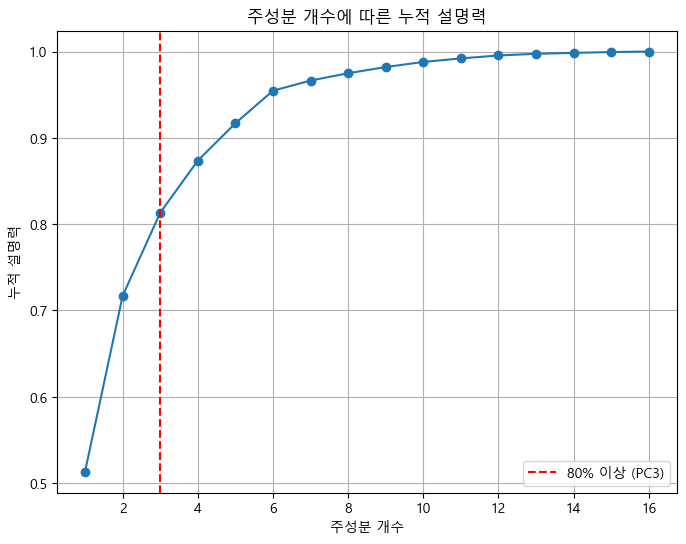

In [ ]:
# 누적 설명력 기준선 (예: 0.80 이상이 되는 지점 찾기)
threshold = 0.80
n_components_80 = np.argmax(cumsum_var >= threshold) + 1  # 1부터 시작하도록 +1

# 그래프 그리기
plt.figure(figsize=(8,6))
plt.plot(range(1, len(cumsum_var)+1), cumsum_var, marker='o')
plt.axvline(x=n_components_80, color='red', linestyle='--', label=f'80% 이상 (PC{n_components_80})')
plt.xlabel('주성분 개수')
plt.ylabel('누적 설명력')
plt.title('주성분 개수에 따른 누적 설명력')
plt.legend()
plt.grid(True)
plt.show()

- 누적 설명력 80% 이상을 위해서 주성분 수 3개로 결정하였습니다.

In [ ]:
def pca_func(df, components) : # 적용할 데이터랑 주성분 수
    # PCA 주성분 2개 구하기 위한 변수 생성
    X = df.copy()

    # 객체
    pca = PCA(n_components= components)

    # 적용
    pca.fit(X)
    x_pca = pca.transform(X)
    pca_df = pd.DataFrame(x_pca)

    # 앞서 구한 주성분이 각각 전체 데이터에서 어느 정도의 설명력을 가지는지 확인
    # -> 전체 분산 대비 어느 정도의 분산 비율을 가지는지 확인
    var = pca.explained_variance_ratio_
    # 주성분 구한 데이터프레임과 각 주성분의 분산 비율을 함께 리턴해주기
    return pca_df, var

pca_3_df, var_2 = pca_func(scaled_df, 3)
pca_3_df.head()

,0,1,2
0,-0.947065,-0.910511,-0.648444
1,-1.556137,-0.500541,-0.282557
2,1.313474,-0.501188,-0.724109
3,1.201223,-0.372285,-0.179004
4,-0.764883,0.476227,-0.140382


In [ ]:
pca_3_df.columns = ['PC1', 'PC2', 'PC3']  # 컬럼 이름 붙이기

### 4-3 K-Means 클러스터링

- Elbow Method (k값 구하기)

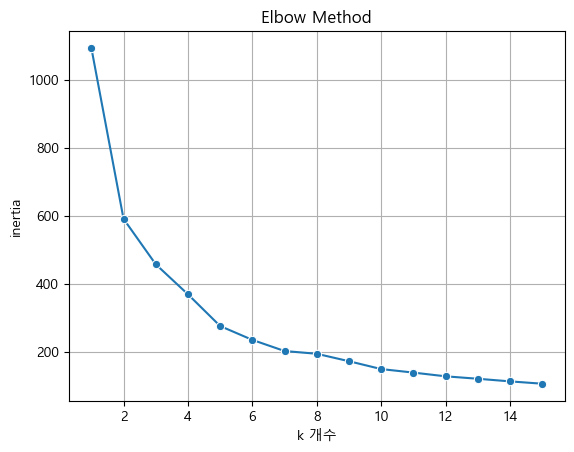

In [ ]:
ks = range(1, 16) # k 의 수 범위 정하기ㅏ 1~15
inertias = []

for k in ks :
    model = KMeans(n_clusters = k, random_state=42)
    model.fit(pca_3_df)
    inertias.append(model.inertia_)

# 시각화
sns.lineplot(x=ks, y=inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('k 개수')
plt.ylabel('inertia')
plt.grid(True)
plt.show()

In [ ]:
# elbow method의 값인 5를 k로 하여서 KMeans
model = KMeans(n_clusters=5,  random_state=42)
model.fit(pca_3_df)
# 고객마다 부여할 클러스터
labels = model.labels_
# PCA 진행한 데이터프레임에 클러스터 번호 부여
pca_km5_df = pca_3_df.copy()
pca_km5_df['label'] = labels
pca_km5_df.head()

,PC1,PC2,PC3,label
0,-0.947065,-0.910511,-0.648444,0
1,-1.556137,-0.500541,-0.282557,3
2,1.313474,-0.501188,-0.724109,0
3,1.201223,-0.372285,-0.179004,0
4,-0.764883,0.476227,-0.140382,0


- Silhouette Score

In [ ]:
# 실루엣 점수 계산
score = silhouette_score(pca_km5_df, labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.530


- 시각화

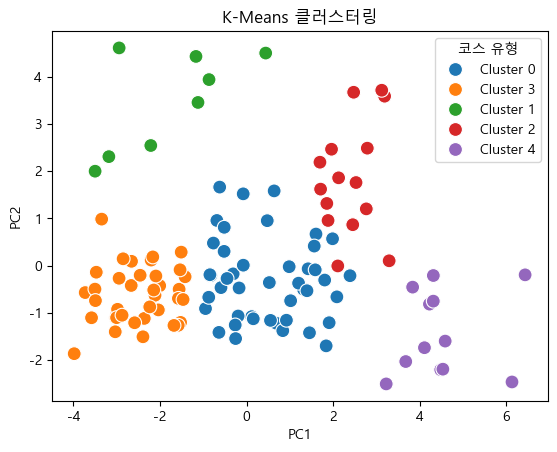

In [ ]:
# 데이터를 가장 잘 설명하는 주성분 1, 2 로 scatterplot 그려보기
label_names = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
    4: 'Cluster 4'
}

# 새 컬럼 추가
pca_km5_df['label_named'] = pca_km5_df['label'].map(label_names)

# 시각화
sns.scatterplot(data=pca_km5_df, x='PC1', y='PC2', hue='label_named', s=100)
plt.title('K-Means 클러스터링')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='코스 유형')
plt.show()

- 데이터 분배 확인

In [ ]:
pca_km5_df['label'].value_counts()

label
0    44
3    39
2    15
4    12
1     8
Name: count, dtype: int64

- 원본 데이터에 클러스터링 라벨 합치기

In [ ]:
original_with_label = merge_df.copy()
original_with_label['label'] = pca_km5_df['label'].values

original_with_label.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,dist_to_nearest_parking_km_label,label
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,0
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0


In [ ]:
# 클러스터별 산별 코스 분배 확인
original_with_label.groupby(['mountain_name', 'label']).size().unstack(fill_value=0)

label,0,1,2,3,4
mountain_name,,,,,
계룡산,4,1,0,4,0
덕유산,5,1,0,3,4
무등산,3,1,1,2,0
북한산,0,0,0,13,0
설악산,4,3,1,5,1
속리산,6,1,6,4,1
오대산,1,0,1,0,6
지리산,9,0,6,1,0
치악산,5,1,0,5,0


In [ ]:
# 클러스터별 평균값 확인
cluster_avg = original_with_label.groupby('label').mean(numeric_only=True)
display(cluster_avg)

,start_lat,start_lon,end_lat,end_lon,schedule,distance_km,duration_min,attraction_count,difficulty,shelter_count,...,start_dist_to_30_stays,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,dist_to_nearest_parking_km_label
label,,,,,,,,,,,,,,,,,,,,,
0,36.289886,127.878734,35.976580,127.661186,1.000000,6.706818,212.840909,4.727273,2.022727,0.022727,...,8.048411,0.684498,3.805894,4.218858,4.956513,2.400540,4.350064,5.524520,6.132469,1.863636
1,36.967233,127.907737,36.675541,127.727141,1.500000,18.400000,623.125000,8.500000,3.000000,0.750000,...,3.622775,3.645617,24.612151,27.467162,31.391963,0.609257,4.323371,5.580863,5.803756,1.250000
2,36.199019,127.848039,36.050096,127.805845,1.333333,13.186667,478.000000,7.066667,2.400000,0.866667,...,11.960140,0.328068,5.905238,6.305461,7.020735,1.570968,7.020779,9.060830,10.304369,1.666667
3,37.014545,127.599495,36.185365,127.560897,1.000000,4.676923,145.897436,4.307692,1.564103,0.128205,...,3.837295,0.626197,1.955202,2.391907,3.025055,1.822110,3.608388,4.352565,4.805070,1.384615
4,37.031516,128.198583,37.463397,128.363394,1.000000,6.016667,198.333333,2.416667,2.083333,0.000000,...,12.708016,1.997172,9.929413,10.364090,11.096239,2.915298,8.982128,11.683626,13.184943,1.250000


### 4-4. 클러스터별 특징 시각화

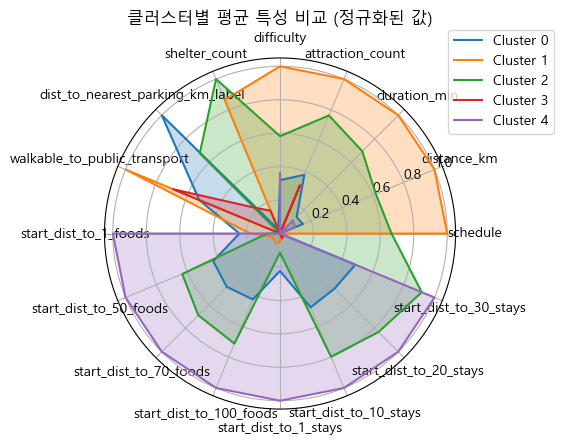

In [ ]:
original_with_label_2 = original_with_label[['schedule', 'distance_km','duration_min','attraction_count', 'difficulty',
                  'shelter_count',
                 'dist_to_nearest_parking_km_label', 'walkable_to_public_transport',
                 'start_dist_to_1_foods', 'start_dist_to_50_foods',
                'start_dist_to_70_foods', 'start_dist_to_100_foods',
                'start_dist_to_1_stays', 'start_dist_to_10_stays',
                'start_dist_to_20_stays', 'start_dist_to_30_stays', 'label']]

# 클러스터 평균 구하기
cluster_mean = original_with_label_2.groupby('label').mean()

# 정규화
scaler = MinMaxScaler()
cluster_mean_scaled = pd.DataFrame(scaler.fit_transform(cluster_mean), columns=cluster_mean.columns)
cluster_mean_scaled['label'] = cluster_mean.index

# 레이더 차트 그리기
labels = cluster_mean.columns
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for i, row in cluster_mean_scaled.iterrows():
    values = row[labels].tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {int(row["label"])}')
    ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('클러스터별 평균 특성 비교 (정규화된 값)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()